In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0
from utils import newfig, fd

import utils as ut
import ei_open_loop as eol
import ei_unified as eu
import ei_jax as ej

In [84]:

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [85]:
nk = 15

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

ti = 0.25

se = eu.solve_eq(
    bd, p,
    t=ti,
    d=0.8,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=10000,
    chk=20,
    prog=True,
)

ni = se.n.copy()

Equilibrium EI:   0%|          | 0/10000 [00:00<?, ?it/s]

In [86]:
t1 = 0.15
t2 = 0.35
kap = 0.3
wc = 5.0

g1 = eu.gam_db(t1, kap=kap, wc=wc)
g2 = eu.gam_db(t2, kap=kap, wc=wc)

dc = (
    eu.Dissipator(g1, name="bath 1"),
    eu.Dissipator(g2, name="bath 2"),
)

bj = (
    ej.gam_db(t1, kap=kap, wc=wc, name="bath 1"),
    ej.gam_db(t2, kap=kap, wc=wc, name="bath 2"),
)

In [87]:
sc = eu.mf_state(bd, p, se.d, se.m)
sj = ej.mf_state(bd, p, se.d, se.m)

ejj = np.asarray(jax.device_get(sj.e))
uj = np.asarray(jax.device_get(sj.u))
vj = np.asarray(jax.device_get(sj.v))

print("Energy error:", np.max(np.abs(sc.e - ejj)))
print("u error:", np.max(np.abs(sc.u - uj)))
print("v error:", np.max(np.abs(sc.v - vj)))

Energy error: 1.5850280021822982e-06
u error: 7.637967369689136e-08
v error: 1.1819222953124431e-07


In [88]:
rc = g1(sc, ni) + g2(sc, ni)
rj = np.asarray(jax.device_get(ej.dense_rates(sj, bj)))

ic = eu.total_current(dc, sc, ni)

ijd = np.asarray(
    jax.device_get(
        ej.dense_current(bd, sj, ni, bj)
    )
)

ijb = np.asarray(
    jax.device_get(
        ej.blocked_current(bd, sj, ni, bj, block=16)
    )
)

print("Rate error:", np.max(np.abs(rc.reshape(rj.shape) - rj)))
print("CPU-JAX current error:", np.max(np.abs(ic - ijd)))
print("Dense-block error:", np.max(np.abs(ijd - ijb)))
print("CPU number rate:", eu.number_rate(ic, bd))
print("JAX number rate:", ej.number_rate(ijd, bd))

Rate error: 6.593891008765951e-07
CPU-JAX current error: 1.2912896223862865e-08
Dense-block error: 1.4551915e-10
CPU number rate: 4.9763185651190145e-21
JAX number rate: -3.495870259939693e-12


In [89]:
kw = dict(
    d=se.d,
    m=se.m,
    dt=0.8,
    td=0.3,
    tm=0.3,
    tol=1.0e-5,
    nmax=10000,
    chk=10,
    prog=True,
)

so_c = eu.solve_open(
    bd, p,
    ni.copy(),
    dc,
    **kw,
)

so_j = ej.solve_open(
    bd, p,
    ni.copy(),
    bj,
    mode="dense",
    **kw,
)

print()
print("CPU")
print("Delta:", so_c.d)
print("m:", so_c.m)
print("error:", so_c.err)
print("iterations:", so_c.it)

print()
print("JAX")
print("Delta:", so_j.d)
print("m:", so_j.m)
print("error:", so_j.err)
print("iterations:", so_j.it)

print()
print("Comparison")
print("Delta error:", abs(so_c.d - so_j.d))
print("m error:", abs(so_c.m - so_j.m))
print("occupation error:", np.max(np.abs(so_c.n - so_j.n)))
print("current error:", np.max(np.abs(so_c.cur - so_j.cur)))

Open EI:   0%|          | 0/10000 [00:00<?, ?it/s]

Open EI JAX:   0%|          | 0/1000 [00:00<?, ?it/s]


CPU
Delta: 1.2812356849375428
m: -0.7903467721916645
error: 9.887146056606136e-06
iterations: 1250

JAX
Delta: 1.2812070846557617
m: -0.7903515100479126
error: 9.838142432272434e-06
iterations: 1250

Comparison
Delta error: 2.86002817810882e-05
m error: 4.737856248104855e-06
occupation error: 3.0709875322110225e-05
current error: 4.9003624333701645e-08


In [115]:
nk = 25

bd = eu.tb_2d(
    nk=nk,
    gap=2.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=3.0,
    n=1.0,
    uh=None,
)

s0 = eu.solve_eq(
    bd, p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

d0 = abs(s0.d)

tc = eu.critical_temperature(
    bd, p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d0)
print("T_c     =", tc)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 0.35266121589144167
T_c     = 0.16627060297876597


In [ ]:
nt = 100

tn = np.linspace(0.03, 2.0, nt)
t1a = tn * tc
t2a = tn * tc

kap = 0.3
wc = 1.0

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    # Cheap equilibrium seed along the diagonal
    se = eu.solve_eq(
        bd, p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 columns",
        leave=False,
    ):
        t1 = t1a[i]

        bs = (
            ej.gam_db(
                t1,
                kap=kap,
                wc=wc,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=kap,
                wc=wc,
                name="bath 2",
            ),
        )

        so = ej.solve_open(
            bd, p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-5,
            nmax=20000,
            chk=20,
            prog=False,
            mode="block",
            block=512,
        )

        n = so.n.copy()
        d = so.d
        m = so.m

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 100/100 [04:51<00:00,  2.91s/it]


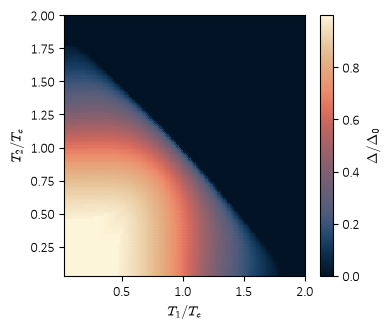

Converged: 10000 / 10000
Largest residual: 9.998679161071777e-06
Largest iteration count: 2960


In [ ]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_V=3_G=2=tb2d_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

In [118]:
ta = 1.0
tb = -0.3
gap = 1.0
n0 = 1.0
nk = 25

bd = eu.tb_2d(
    nk=nk,
    gap=gap,
    ta=ta,
    tb=tb,
)

nv = 61
va = ta * np.linspace(0.01, 8.0, nv)

t00= 0.1
ra = np.array([0.03, 0.05, 0.08, 0.1, 0.25, 1.0])

kap = 0.3
wc = 5.0

da = np.full((ra.size, nv), np.nan)
ma = np.full_like(da, np.nan)
er = np.full_like(da, np.nan)
ok = np.zeros_like(da, dtype=bool)

In [119]:
deq = np.full(nv, np.nan)
meq = np.full(nv, np.nan)
eeq = np.full(nv, np.nan)

d = 1.0
m = 0.0

for j in tqdm(
    range(nv - 1, -1, -1),
    desc="Equilibrium V sweep",
):
    p = eu.MFPars(
        v=va[j],
        n=n0,
        uh=None,
    )

    se = eu.solve_eq(
        bd, p,
        t=t00,
        d=max(abs(d), 1.0e-4),
        m=m,
        mix=(0.15, 0.15),
        tol=1.0e-8,
        nmax=30000,
        chk=20,
        prog=False,
    )

    d = se.d
    m = se.m

    deq[j] = abs(se.d) / ta
    meq[j] = se.m
    eeq[j] = se.err

Equilibrium V sweep: 100%|██████████| 61/61 [00:59<00:00,  1.02it/s]


In [120]:
for ir in tqdm(range(ra.size), desc="Temperature ratios"):
    rr = ra[ir]


    # Initial state at the largest interaction
    ph = eu.MFPars(
        v=va[-1],
        n=n0,
        uh=None,
    )

    se = eu.solve_eq(
        bd, ph,
        t=t00,
        d=1.0,
        m=0.0,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for j in tqdm(
        range(nv - 1, -1, -1),
        desc=f"T1/T2={rr:g}",
        leave=False,
    ):
        v0 = va[j]

        # The default keeps U_H equal to V
        p = eu.MFPars(
            v=v0,
            n=n0,
            uh=None,
        )

        bs = (
            ej.gam_db(
                t00 / np.sqrt(rr),
                kap=kap,
                wc=wc,
                name="bath 1",
            ),
            ej.gam_db(
                t00 * np.sqrt(rr),
                kap=kap,
                wc=wc,
                name="bath 2",
            ),
        )

        so = ej.solve_open(
            bd, p,
            n,
            bs,
            d=max(abs(d), 1.0e-1),
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=2.0e-6,
            nmax=20000,
            chk=20,
            prog=False,
            mode="dense",
        )

        n = so.n.copy()
        d = so.d
        m = so.m

        da[ir, j] = abs(so.d) / ta
        ma[ir, j] = so.m
        er[ir, j] = so.err
        ok[ir, j] = so.ok

Temperature ratios: 100%|██████████| 6/6 [00:46<00:00,  7.80s/it]


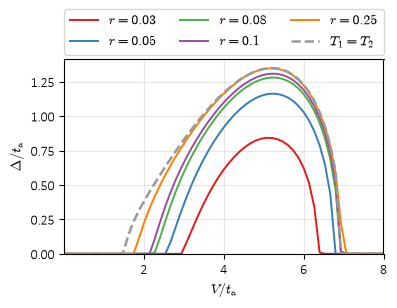

In [121]:
h = 0.8
fig, ax = plt.subplots(figsize=(4, h * 4))

for i, rr in enumerate(ra[:-1]):
    ax.plot(
        va / ta,
        da[i],
        color=set1_list[i],
        lw=1.4,
        label=rf"$r={rr:g}$",
    )

ax.plot(
    va / ta,
    deq,
    "--",
    color=set1_list[len(ra)],
    lw=1.8,
    label=r"$T_1=T_2$",
)

ax.set_xlabel(r"$V/t_a$")
ax.set_ylabel(r"$\Delta/t_a$")
ax.set_xlim((va / ta).min(), (va / ta).max())
ax.set_ylim(bottom=0.0)
ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout()
# plt.savefig("Delta_V_fixT1vsT2.pdf")
plt.show()